In [1]:
import pandas as pd
import numpy as np

# Create a synthetic dataset
np.random.seed(42)
data_size = 1000

data = pd.DataFrame({
    'temperature': np.random.normal(60, 10, data_size),
    'pressure': np.random.normal(100, 15, data_size),
    'vibration': np.random.normal(1.5, 0.5, data_size),
    'rpm': np.random.normal(1500, 200, data_size),
    'usage_hours': np.random.randint(1, 5000, data_size),
})

# Create a 'failure' target based on logic (e.g., high temp + high vibration = failure)
data['failure'] = ((data['temperature'] > 80) | (data['vibration'] > 2.5) | (data['usage_hours'] > 4500)).astype(int)

# Save to CSV
data.to_csv("predictive_maintenance.csv", index=False)
print("Synthetic dataset 'predictive_maintenance.csv' created!")

Synthetic dataset 'predictive_maintenance.csv' created!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Dataset
data = pd.read_csv("predictive_maintenance.csv")

# 2. Feature Selection
X = data[['temperature', 'pressure', 'vibration', 'rpm', 'usage_hours']]
y = data['failure']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Prediction
y_pred = rf_model.predict(X_test)

Overall Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       1.00      1.00      1.00        22

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



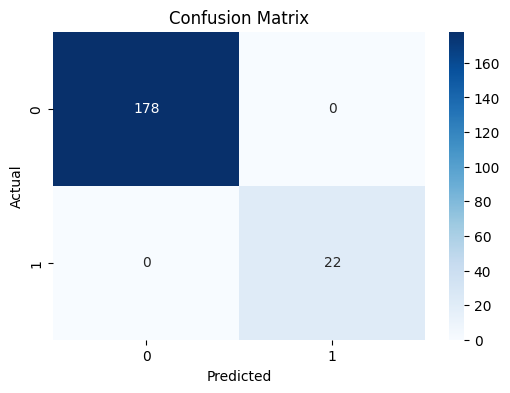

/tmp/ipykernel_8671/3143551097.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


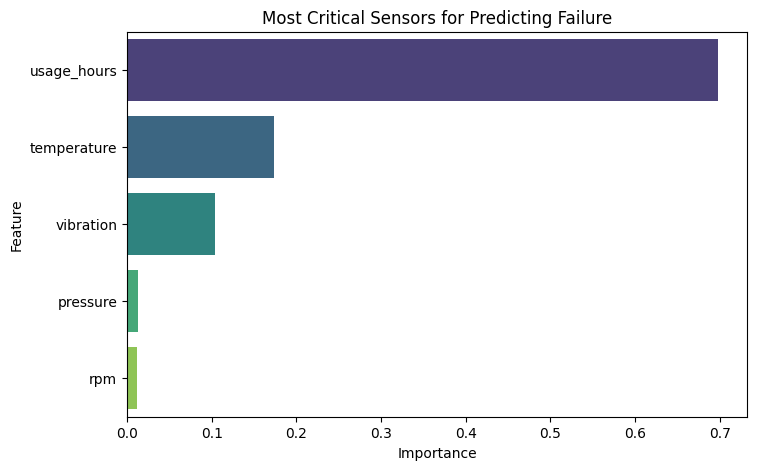

In [3]:
# 6. Evaluation Metrics
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Visualization: Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 8. Visualization: Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Most Critical Sensors for Predicting Failure')
plt.show()